Skipping, found downloaded files in "./classification-of-malwares" (use force=True to force download)
=== Dataset Info ===
Shape: (5210, 70)
   e_cblp  e_cp  e_cparhdr  e_maxalloc  e_sp  e_lfanew  NumberOfSections  \
0     144     3          4       65535   184       256                 4   
1     144     3          4       65535   184       184                 4   
2     144     3          4       65535   184       272                 5   
3     144     3          4       65535   184       184                 1   
4     144     3          4       65535   184       224                 5   

   CreationYear  FH_char0  FH_char1  ...  sus_sections  non_sus_sections  \
0             1         0         1  ...             1                 3   
1             1         0         1  ...             1                 3   
2             1         0         1  ...             1                 4   
3             1         0         1  ...             0                 1   
4             1       

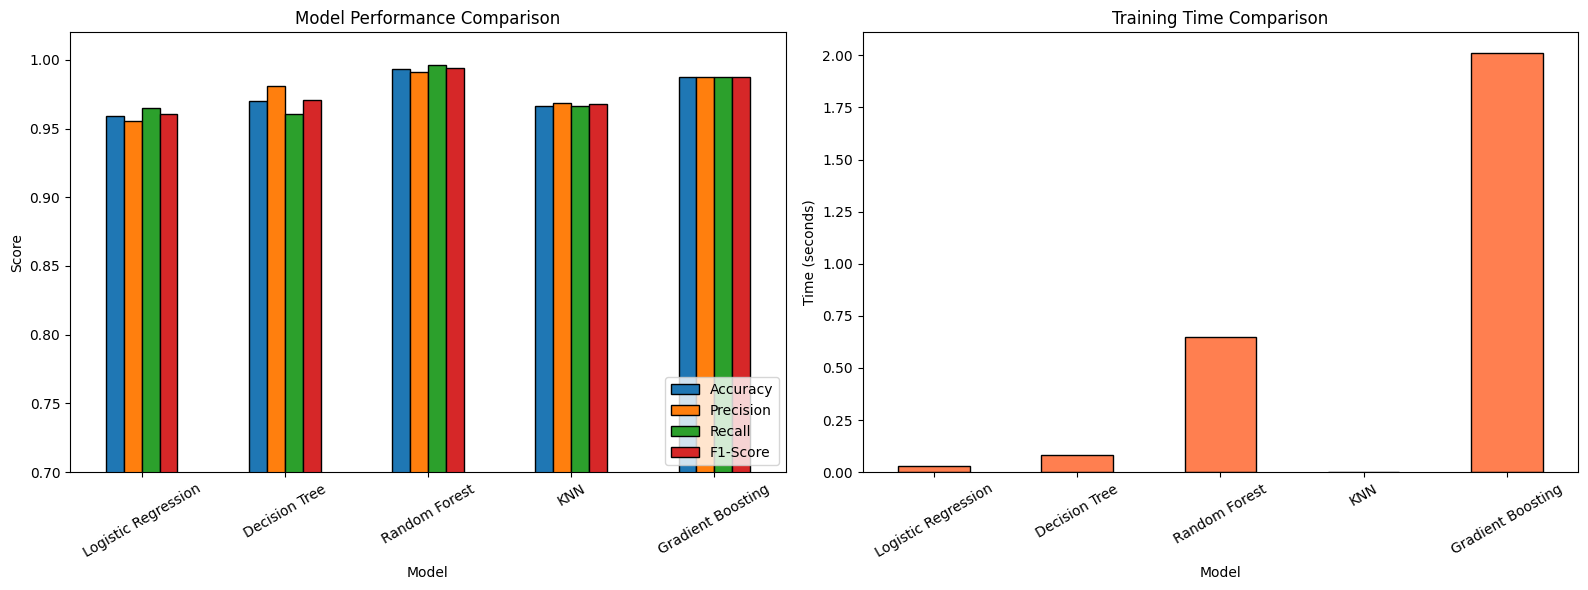

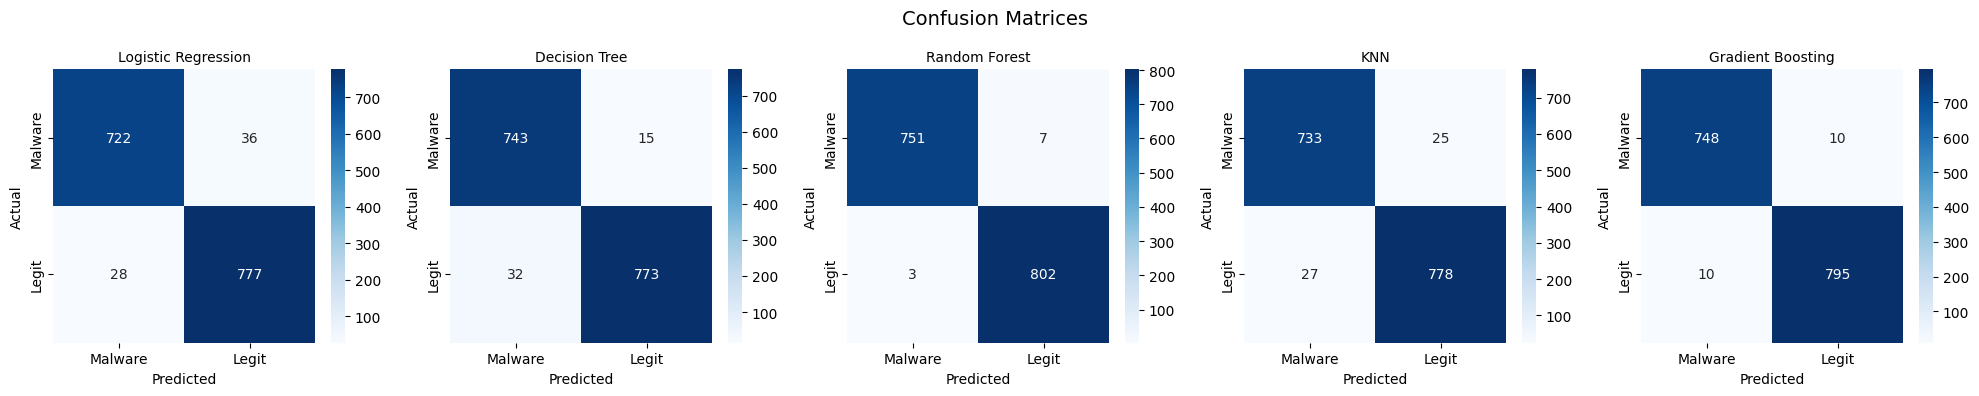

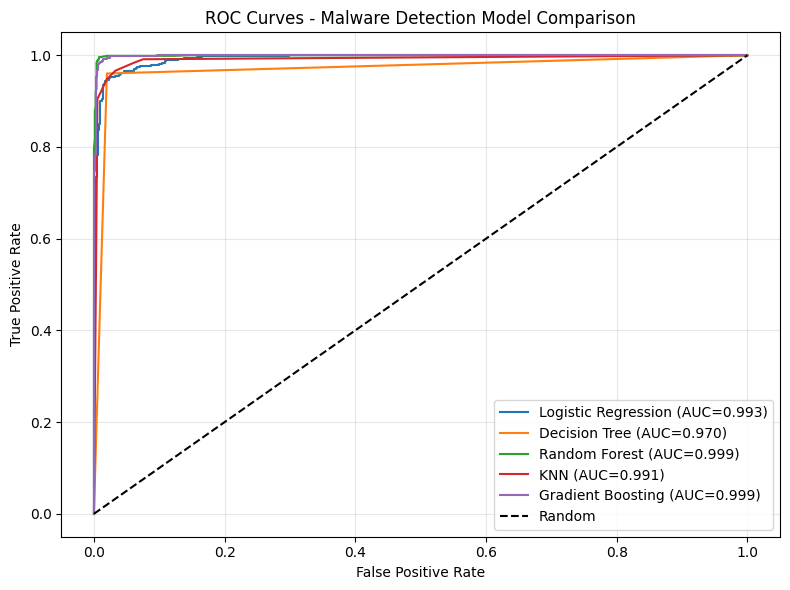


=== Best Model: Random Forest ===
Accuracy: 0.9936 | F1-Score: 0.9938


In [9]:
# Experiment 5: ML System Implementation & Performance Comparison
# Topic: Machine Learning in Malware Detection and Penetration Testing

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, classification_report,
                             roc_curve, auc)
import time

# 1. Load Dataset
!pip install opendatasets -q
import opendatasets as od
od.download("https://www.kaggle.com/datasets/saurabhshahane/classification-of-malwares")
df = pd.read_csv("classification-of-malwares/ClaMP_Integrated-5184.csv")

print("=== Dataset Info ===")
print(f"Shape: {df.shape}")
print(df.head())
print(f"\n=== Class Distribution ===")
print(df['class'].value_counts().rename({0: 'Malware', 1: 'Legitimate'}))

# 2. Preprocessing
df = df.select_dtypes(include=[np.number]).dropna()

X = df.drop('class', axis=1)
y = df['class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f"\nTraining: {X_train.shape[0]} | Test: {X_test.shape[0]}")

# 3. Define Models
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# 4. Train, Evaluate & Compare
results = []

for name, model in models.items():
    print(f"\n{'='*50}")
    print(f"Training: {name}")

    start = time.time()
    model.fit(X_train, y_train)
    train_time = time.time() - start

    y_pred = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred)
    rec = recall_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)

    results.append({
        'Model': name,
        'Accuracy': acc,
        'Precision': prec,
        'Recall': rec,
        'F1-Score': f1,
        'Train Time (s)': round(train_time, 2)
    })

    print(f"Accuracy: {acc:.4f} | Precision: {prec:.4f} | Recall: {rec:.4f} | F1: {f1:.4f} | Time: {train_time:.2f}s")
    print(classification_report(y_test, y_pred, target_names=['Malware','Legitimate']))

# 5. Performance Comparison Table
results_df = pd.DataFrame(results)
print("\n=== Performance Comparison ===")
print(results_df.to_string(index=False))

# 6. Visualization - Metrics Comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
results_df.set_index('Model')[metrics].plot(kind='bar', ax=axes[0], edgecolor='black')
axes[0].set_title("Model Performance Comparison")
axes[0].set_ylabel("Score")
axes[0].set_ylim(0.7, 1.02)
axes[0].legend(loc='lower right')
axes[0].tick_params(axis='x', rotation=30)

results_df.set_index('Model')['Train Time (s)'].plot(kind='bar', ax=axes[1],
    color='coral', edgecolor='black')
axes[1].set_title("Training Time Comparison")
axes[1].set_ylabel("Time (seconds)")
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.show()

# 7. Confusion Matrices
fig, axes = plt.subplots(1, len(models), figsize=(20, 4))
for i, (name, model) in enumerate(models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Malware','Legit'], yticklabels=['Malware','Legit'])
    axes[i].set_title(name, fontsize=10)
    axes[i].set_xlabel("Predicted")
    axes[i].set_ylabel("Actual")
plt.suptitle("Confusion Matrices", fontsize=14)
plt.tight_layout()
plt.show()

# 8. ROC Curves
plt.figure(figsize=(8, 6))
for name, model in models.items():
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_test)[:, 1]
    else:
        y_prob = model.decision_function(X_test)
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC={roc_auc:.3f})')

plt.plot([0,1], [0,1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves - Malware Detection Model Comparison')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 9. Best Model
best = results_df.loc[results_df['F1-Score'].idxmax()]
print(f"\n=== Best Model: {best['Model']} ===")
print(f"Accuracy: {best['Accuracy']:.4f} | F1-Score: {best['F1-Score']:.4f}")